<a href="https://colab.research.google.com/github/savioshaju/MNIST-Image-Classification-with-CNN/blob/main/minist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Image Classification with CNN

## 1. Imports and Setup

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os # Added for path manipulation
import pandas as pd # Added for classification report DataFrame conversion
import seaborn as sns # Added for confusion matrix visualization
from google.colab import drive # Import drive

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

# Mount Google Drive
drive.mount('/content/drive')
# Define save path in Google Drive
save_base_path = '/content/drive/MyDrive/mnist_results'
os.makedirs(save_base_path, exist_ok=True)
print(f"Results (images and models) will be saved to: {save_base_path}")

# Check and Configure GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs available and configured: {len(gpus)}")
        for gpu in gpus:
            print(gpu)
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found. Using CPU.")


(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

# Normalize
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Fixed validation split
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

x_val = x_train_full[50000:]
y_val = y_train_full[50000:]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

TensorFlow Version: 2.20.0
Mounted at /content/drive
Results (images and models) will be saved to: /content/drive/MyDrive/mnist_results
GPUs available and configured: 1
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (50000, 28, 28, 1)
Validation: (10000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## 2. Baseline Model

### 2.1 Model Training

In [ ]:
baseline_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

baseline_model.evaluate(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9313 - loss: 0.2326 - val_accuracy: 0.9783 - val_loss: 0.0747
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9799 - loss: 0.0651 - val_accuracy: 0.9833 - val_loss: 0.0561
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9862 - loss: 0.0452 - val_accuracy: 0.9868 - val_loss: 0.0462
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9900 - loss: 0.0338 - val_accuracy: 0.9887 - val_loss: 0.0419
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0281 - val_accuracy: 0.9882 - val_loss: 0.0418
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9927 - loss: 0.0238 - val_accuracy: 0.9890 - val_loss: 0.0384
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9948 - loss: 0.0162 - val_accuracy: 0.9885 - val_loss: 0.0438
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9953 - loss: 0.0148 - val_accuracy: 

[0.0366230346262455, 0.9878000020980835]

In [ ]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

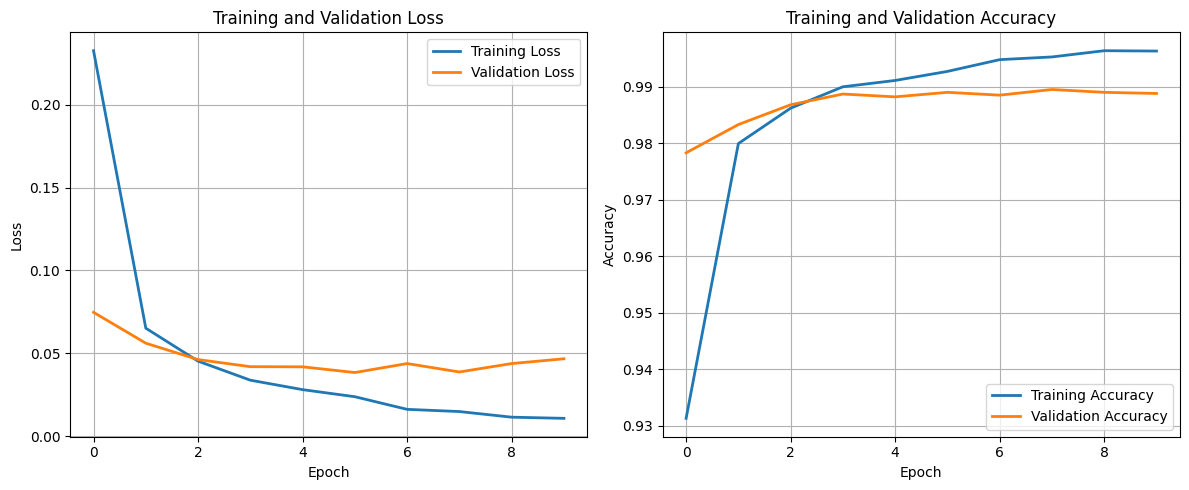

In [ ]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history_baseline.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_baseline.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_base_path, 'training_curves_baseline.png')) # Save the figure
plt.show()

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_baseline.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_baseline.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_baseline.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_baseline.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9963
Validation Accuracy : 0.9888
Test Accuracy       : 0.9878
Training Loss       : 0.0107
Validation Loss     : 0.0467
Test Loss           : 0.0366


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


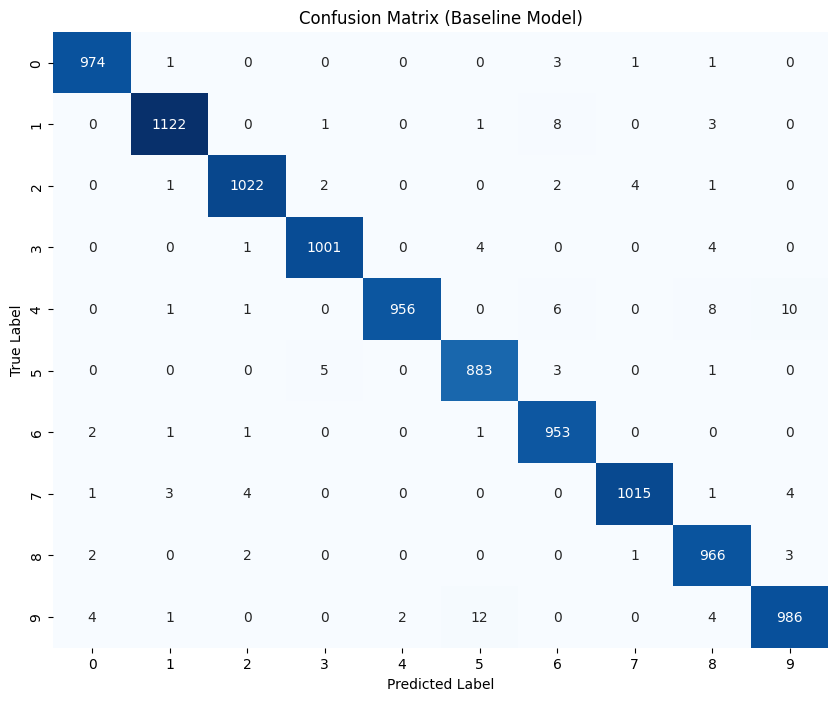

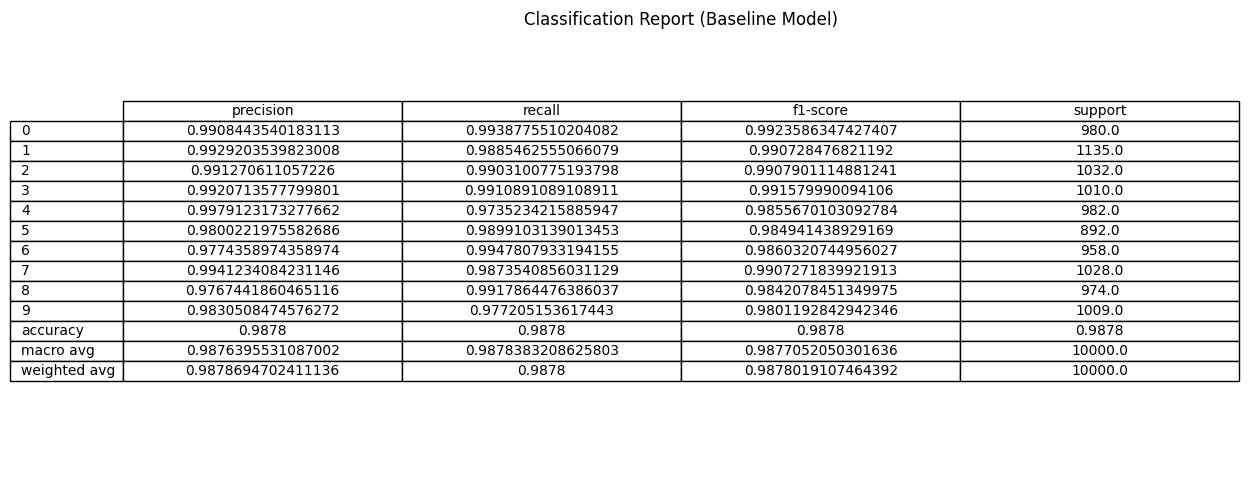

Confusion Matrix (Baseline Model):
[[ 974    1    0    0    0    0    3    1    1    0]
 [   0 1122    0    1    0    1    8    0    3    0]
 [   0    1 1022    2    0    0    2    4    1    0]
 [   0    0    1 1001    0    4    0    0    4    0]
 [   0    1    1    0  956    0    6    0    8   10]
 [   0    0    0    5    0  883    3    0    1    0]
 [   2    1    1    0    0    1  953    0    0    0]
 [   1    3    4    0    0    0    0 1015    1    4]
 [   2    0    2    0    0    0    0    1  966    3]
 [   4    1    0    0    2   12    0    0    4  986]]

Classification Report (Baseline Model):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.97      0.99       982
           5       0.98      0.99      0.98       892
           6  

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Get predictions for the test set
y_pred_baseline = np.argmax(baseline_model.predict(x_test), axis=1)

# Confusion Matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix (Baseline Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(save_base_path, 'confusion_matrix_baseline.png'))
plt.show() # Display the plot in the notebook
plt.close() # Close the figure to free memory

# Classification Report
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True)
# Convert to DataFrame for better display
df_report_baseline = pd.DataFrame(report_baseline).transpose()

plt.figure(figsize=(12, 6))
ax = plt.gca() # Get current axes
ax.axis('off') # Hide axes
tbl = ax.table(cellText=df_report_baseline.values,
               colLabels=df_report_baseline.columns,
               rowLabels=df_report_baseline.index,
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2) # Adjust size
plt.title('Classification Report (Baseline Model)', y=0.95) # Adjust title position
plt.savefig(os.path.join(save_base_path, 'classification_report_baseline.png'), bbox_inches='tight')
plt.show() # Display the plot in the notebook
plt.close()

print('Confusion Matrix (Baseline Model):')
print(cm_baseline) # Still print for console output

print('\nClassification Report (Baseline Model):')
print(classification_report(y_test, y_pred_baseline)) # Still print for console output

In [ ]:
baseline_model.save(os.path.join(save_base_path, "baseline_model.keras"))

## 3. Overfitting Model

### 3.1 Model Training (Overfit)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

overfit_model = Sequential([

    Input(shape=(28,28,1)),

    # Block 1
    Conv2D(128, (3,3), padding='same', activation='relu'),
    Conv2D(128, (3,3), padding='same', activation='relu'),

    # Block 2 (No pooling yet)
    Conv2D(256, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),

    # First pooling
    MaxPooling2D(pool_size=(2,2)),

    # Block 3
    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),

    # No second pooling

    Flatten(),

    Dense(4096, activation='relu'),
    Dense(2048, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),

    Dense(10, activation='softmax')
])

overfit_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_overfit = overfit_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=150,
    batch_size=128,
    verbose=1
)

Epoch 1/150
  4/391 ━━━━━━━━━━━━━━━━━━━━ 4:11:41 39s/step - accuracy: 0.1174 - loss: 2.9804

In [ ]:
overfit_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │    16,779,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,619,936 (269.39 MB)

 Trainable params: 23,539,978 (89.80 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,079,958 (179.60 MB)

In [ ]:
train_loss, train_accuracy = overfit_model.evaluate(x_train, y_train, verbose=0)
val_loss, val_accuracy = overfit_model.evaluate(x_val, y_val, verbose=0)
test_loss, test_accuracy = overfit_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9996
Validation Accuracy : 0.9919
Test Accuracy       : 0.9941
Training Loss       : 0.0032
Validation Loss     : 0.0929
Test Loss           : 0.0662


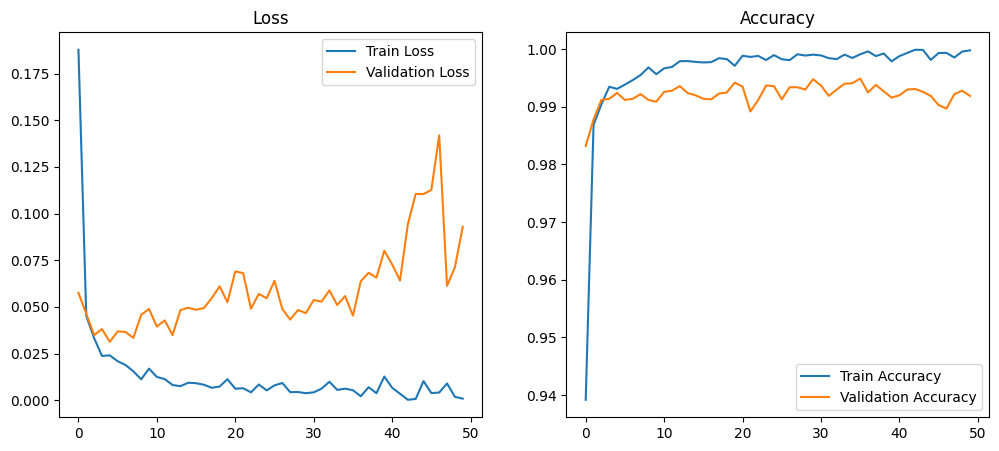

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_overfit.history['accuracy'], label='Train Accuracy')
plt.plot(history_overfit.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.savefig(os.path.join(save_base_path, 'training_curves_overfit.png')) # Save the figure
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

y_pred_overfit = np.argmax(overfit_model.predict(x_test), axis=1)

# Confusion Matrix
cm_overfit = confusion_matrix(y_test, y_pred_overfit)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_overfit, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix (Overfit Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(save_base_path, 'confusion_matrix_overfit.png'))
plt.show()
plt.close()

# Classification Report
report_overfit = classification_report(y_test, y_pred_overfit, output_dict=True)
df_report_overfit = pd.DataFrame(report_overfit).transpose()

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.axis('off')
tbl = ax.table(cellText=df_report_overfit.values,
               colLabels=df_report_overfit.columns,
               rowLabels=df_report_overfit.index,
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title('Classification Report (Overfit Model)', y=0.95)
plt.savefig(os.path.join(save_base_path, 'classification_report_overfit.png'), bbox_inches='tight')
plt.show()
plt.close()

print('Confusion Matrix (Overfit Model):')
print(cm_overfit)

print('\nClassification Report (Overfit Model):')
print(classification_report(y_test, y_pred_overfit))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


NameError: name 'confusion_matrix' is not defined

In [ ]:
overfit_model.save(os.path.join(save_base_path, "overfit_model.keras"))
print(f"Overfit model saved to {os.path.join(save_base_path, 'overfit_model.keras')}")

Sample Predictions (Overfit Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


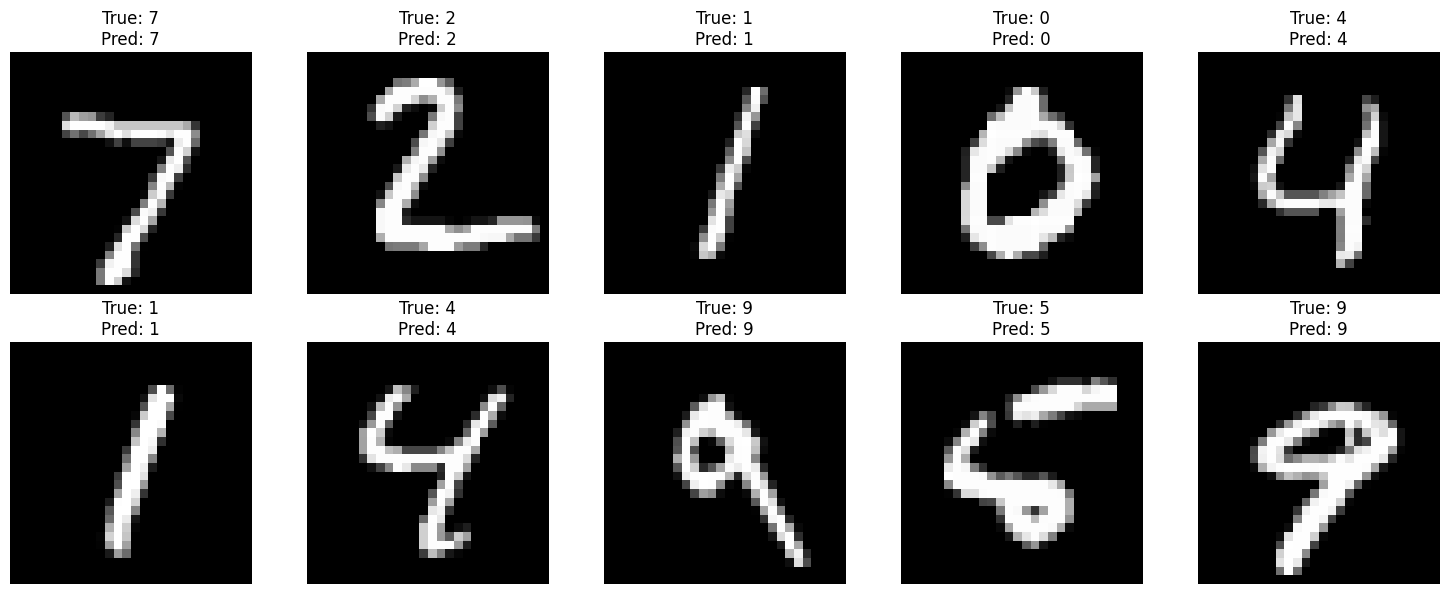

In [ ]:
print('Sample Predictions (Overfit Model):')
plot_predictions(overfit_model, x_test, y_test, num_samples=10)

## 4. Regularized Model

### 4.1 Model Training (Regularized)

In [ ]:
same_arch_model = Sequential([
    tf.keras.Input(shape=(28,28,1)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(1024,activation='relu'),
    Dense(512,activation='relu'),

    Dense(10,activation='softmax')
])

same_arch_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(

    ),
    metrics=['accuracy']
)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

history_fixed = same_arch_model.fit(
    datagen.flow(x_train,y_train,batch_size=128),
    validation_data=(x_val,y_val),
    epochs=50,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

same_arch_model.evaluate(x_test,y_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9199 - loss: 0.2506 - val_accuracy: 0.9805 - val_loss: 0.0614 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9772 - loss: 0.0717 - val_accuracy: 0.9893 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9812 - loss: 0.0595 - val_accuracy: 0.9919 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9845 - loss: 0.0493 - val_accuracy: 0.9920 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9868 - loss: 0.0426 - val_accuracy: 0.9918 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9889 - loss: 0.0379 - val_accuracy: 0.9925 - val_loss: 0.0254 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9886 - l

[0.016334209591150284, 0.994700014591217]

In [ ]:
same_arch_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,143,008 (84.47 MB)

 Trainable params: 7,381,002 (28.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,762,006 (56.31 MB)

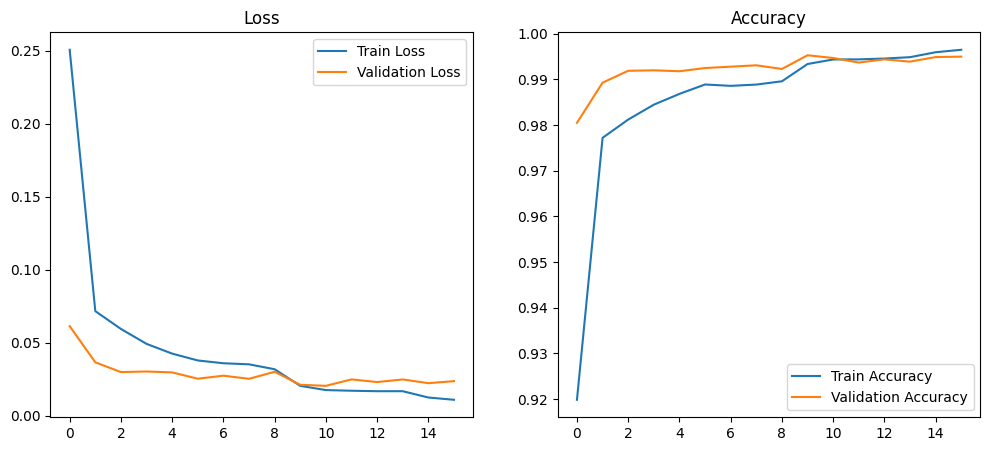

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_fixed.history['loss'], label='Train Loss')
plt.plot(history_fixed.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_fixed .history['accuracy'], label='Train Accuracy')
plt.plot(history_fixed.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.savefig(os.path.join(save_base_path, 'training_curves_regularized.png')) # Save the figure
plt.show()

In [ ]:
test_loss, test_accuracy = same_arch_model.evaluate(x_test, y_test, verbose=0)

print(f"Training Accuracy   : {history_fixed.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history_fixed.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

print(f"Training Loss       : {history_fixed.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history_fixed.history['val_loss'][-1]:.4f}")
print(f"Test Loss           : {test_loss:.4f}")

Training Accuracy   : 0.9965
Validation Accuracy : 0.9950
Test Accuracy       : 0.9947
Training Loss       : 0.0110
Validation Loss     : 0.0237
Test Loss           : 0.0163


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


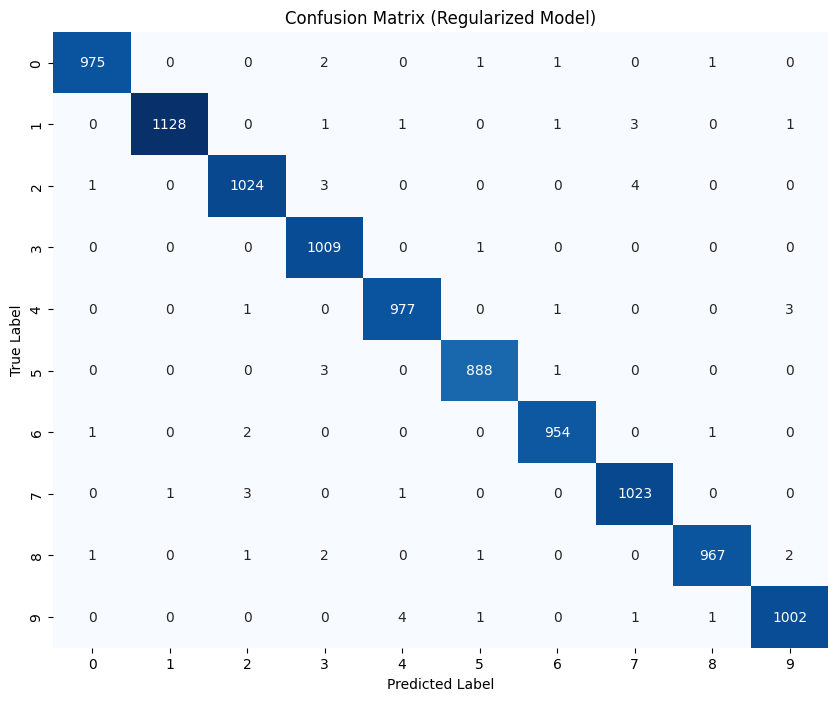

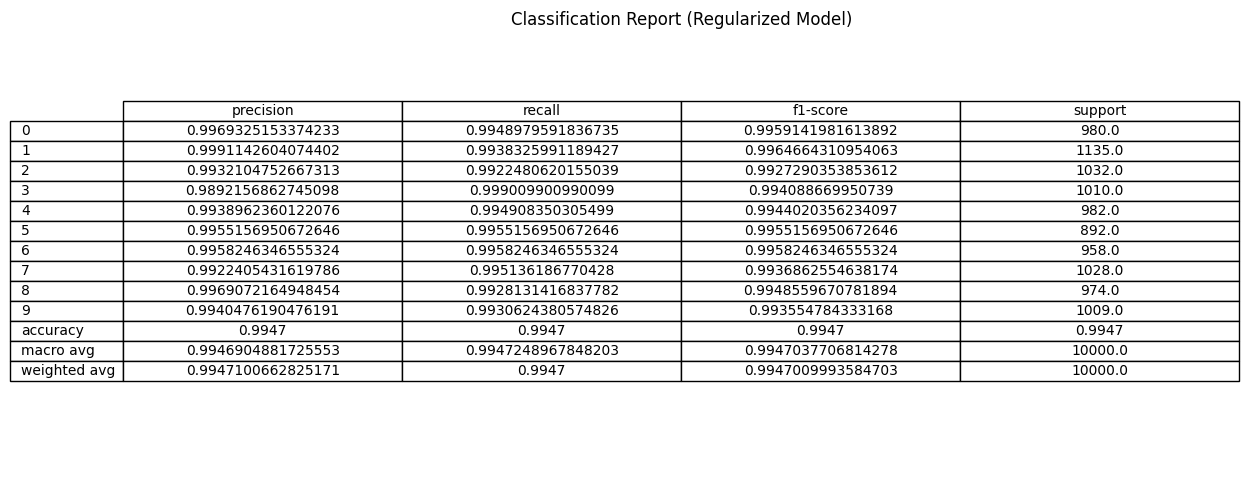

Confusion Matrix (Regularized Model):
[[ 975    0    0    2    0    1    1    0    1    0]
 [   0 1128    0    1    1    0    1    3    0    1]
 [   1    0 1024    3    0    0    0    4    0    0]
 [   0    0    0 1009    0    1    0    0    0    0]
 [   0    0    1    0  977    0    1    0    0    3]
 [   0    0    0    3    0  888    1    0    0    0]
 [   1    0    2    0    0    0  954    0    1    0]
 [   0    1    3    0    1    0    0 1023    0    0]
 [   1    0    1    2    0    1    0    0  967    2]
 [   0    0    0    0    4    1    0    1    1 1002]]

Classification Report (Regularized Model):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      1.00      1.00       892
        

In [ ]:
y_pred_fixed = np.argmax(same_arch_model.predict(x_test), axis=1)

# Confusion Matrix
cm_fixed = confusion_matrix(y_test, y_pred_fixed)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_fixed, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title('Confusion Matrix (Regularized Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(save_base_path, 'confusion_matrix_regularized.png'))
plt.show()
plt.close()

# Classification Report
report_fixed = classification_report(y_test, y_pred_fixed, output_dict=True)
df_report_fixed = pd.DataFrame(report_fixed).transpose()

plt.figure(figsize=(12, 6))
ax = plt.gca()
ax.axis('off')
tbl = ax.table(cellText=df_report_fixed.values,
               colLabels=df_report_fixed.columns,
               rowLabels=df_report_fixed.index,
               loc='center',
               cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title('Classification Report (Regularized Model)', y=0.95)
plt.savefig(os.path.join(save_base_path, 'classification_report_regularized.png'), bbox_inches='tight')
plt.show()
plt.close()

print('Confusion Matrix (Regularized Model):')
print(cm_fixed)

print('\nClassification Report (Regularized Model):')
print(classification_report(y_test, y_pred_fixed))

Sample Predictions (Regularized Model):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


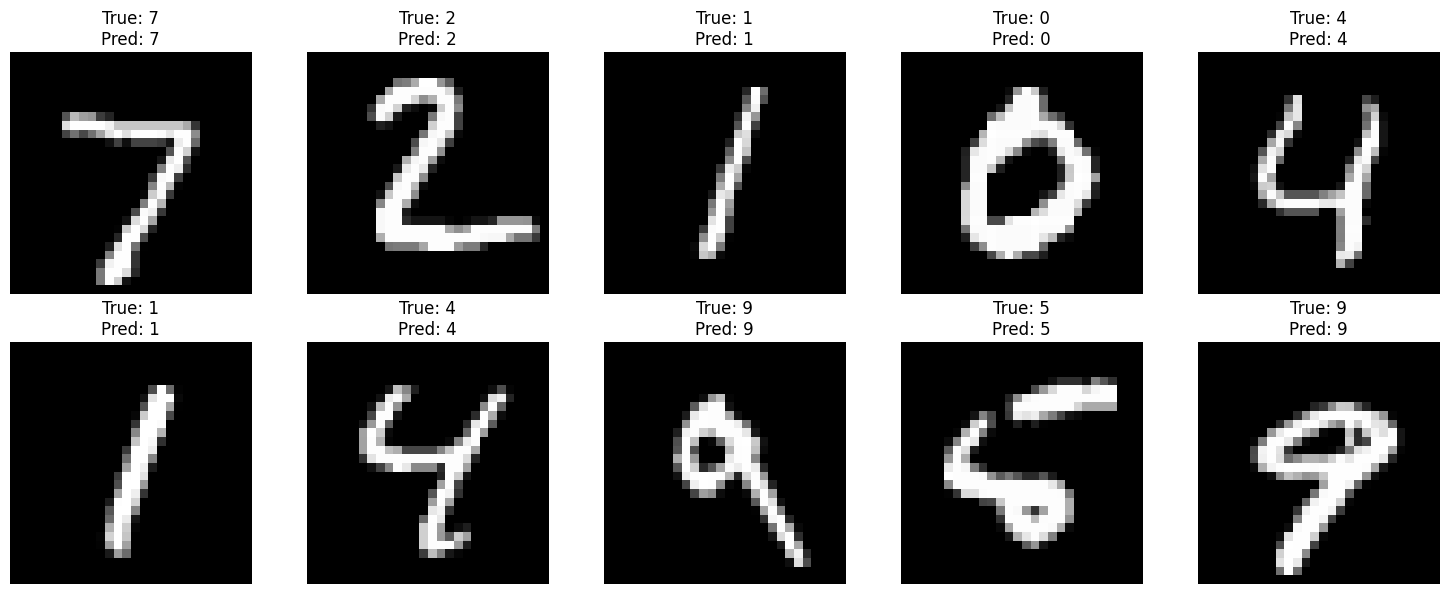

In [ ]:
print('Sample Predictions (Regularized Model):')
plot_predictions(same_arch_model, x_test, y_test, num_samples=10)

In [ ]:
same_arch_model.save(os.path.join(save_base_path, "same_arch_model.keras"))

In [ ]:
ls

baseline_model.keras  same_arch_model.keras


## 3. Experiment 2: Intentionally Overfitting MLP

Here we intentionally overfit a model by using a massive Multilayer Perceptron (MLP) architecture with high capacity and no regularization techniques.
We use large Dense layers (2048 and 1024 neurons) and train for 150 epochs. No Dropout, BatchNormalization, L2 decay, or Data Augmentation is used.

In [ ]:
# Define the Overfitting MLP Architecture
overfit_mlp_model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(2048, activation='relu'),
    Dense(2048, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(10, activation='softmax')
])

overfit_mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

overfit_mlp_model.summary()

# Train for 150 epochs to force overfitting
history_overfit_mlp = overfit_mlp_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2048)           │     1,607,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,912,458 (30.18 MB)

 Trainable params: 7,912,458 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.9365 - loss: 0.2051 - val_accuracy: 0.9681 - val_loss: 0.1102
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9725 - loss: 0.0898 - val_accuracy: 0.9676 - val_loss: 0.1141
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9751 - val_loss: 0.0876
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9858 - loss: 0.0456 - val_accuracy: 0.9768 - val_loss: 0.0810
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9883 - loss: 0.0368 - val_accuracy: 0.9760 - val_loss: 0.0967
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9910 - loss: 0.0301 - val_accuracy: 0.9772 - val_loss: 0.0866
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9916 - loss: 0.0275 - val_accuracy: 0.9744 - val_loss: 0.1139
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9918 - loss: 0.0266 - val_accuracy: 

Experiment 2 - Training Accuracy   : 0.9982, Loss: 0.0107
Experiment 2 - Validation Accuracy : 0.9824, Loss: 0.1525
Experiment 2 - Test Accuracy       : 0.9810, Loss: 0.1445


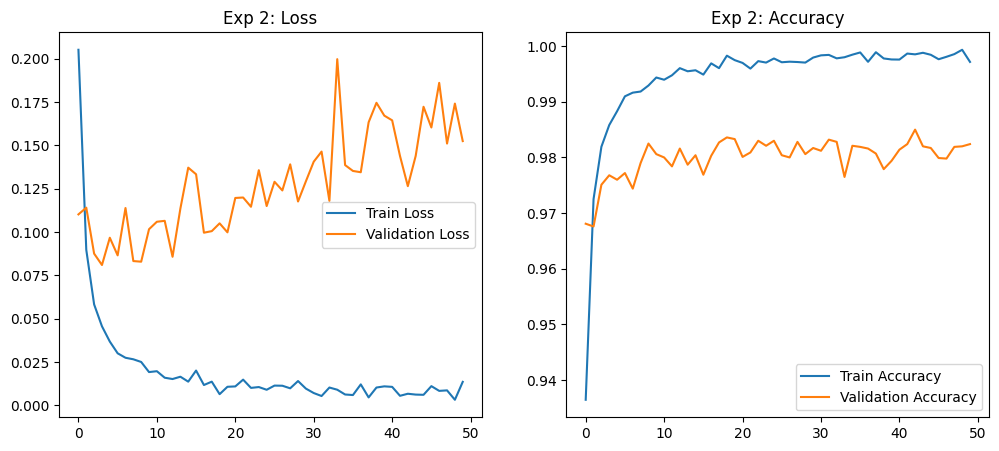

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


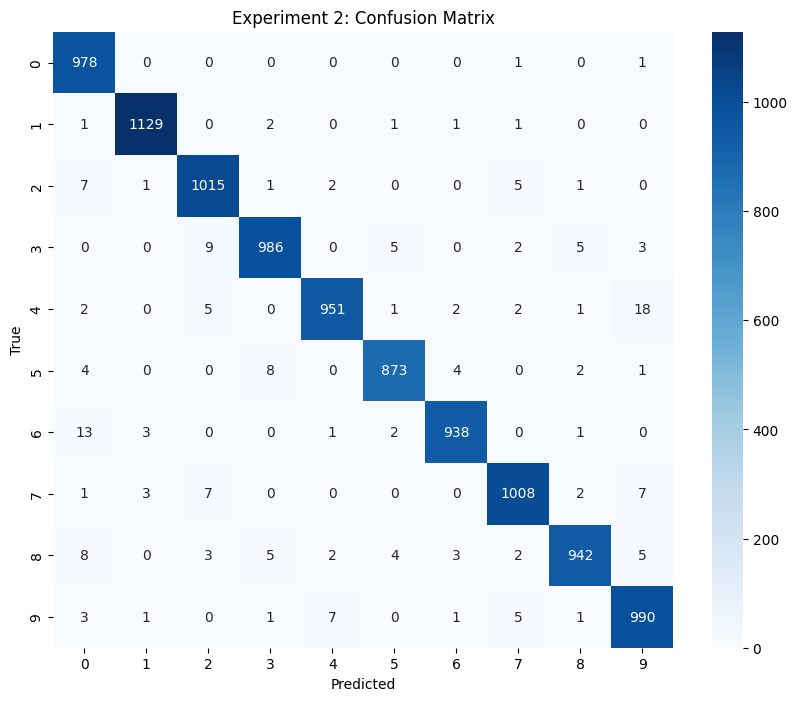

In [ ]:
# Evaluate and Plot Experiment 2
train_loss, train_accuracy = overfit_mlp_model.evaluate(x_train, y_train, verbose=0)
val_loss, val_accuracy = overfit_mlp_model.evaluate(x_val, y_val, verbose=0)
test_loss, test_accuracy = overfit_mlp_model.evaluate(x_test, y_test, verbose=0)

print(f"Experiment 2 - Training Accuracy   : {train_accuracy:.4f}, Loss: {train_loss:.4f}")
print(f"Experiment 2 - Validation Accuracy : {val_accuracy:.4f}, Loss: {val_loss:.4f}")
print(f"Experiment 2 - Test Accuracy       : {test_accuracy:.4f}, Loss: {test_loss:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_overfit_mlp.history['loss'], label='Train Loss')
plt.plot(history_overfit_mlp.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Exp 2: Loss")

plt.subplot(1, 2, 2)
plt.plot(history_overfit_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_overfit_mlp.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Exp 2: Accuracy")

plt.savefig(os.path.join(save_base_path, 'training_curves_overfit_mlp.png'))
plt.show()

# Confusion Matrix
y_pred_probs = overfit_mlp_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = tf.math.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Experiment 2: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## 4. Experiment 3: Regularized MLP (Same Architecture)

Here we take EXACTLY the same layer structure as Experiment 2 (Flatten, Dense 2048, Dense 2048, Dense 1024, Dense 10) and reduce overfitting ONLY by applying regularization techniques.
Specifically, we use:
- **Dropout(0.5)** between the Dense layers. (Dropout acts as a regularization mask during training and does not change the model's fundamental capacity).
- **L2 Weight Decay** applied to the Dense kernels.
- **AdamW Optimizer** which naturally incorporates weight decay.
- **EarlyStopping** and **ReduceLROnPlateau** callbacks.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

# L2 regularization factor
l2_reg = regularizers.l2(1e-4)

# Regularized MLP Architecture (Identical Dense layers to Exp 2)
regularized_mlp_model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(2048, activation='relu', kernel_regularizer=l2_reg),
    tf.keras.layers.Dropout(0.5),
    Dense(2048, activation='relu', kernel_regularizer=l2_reg),
    tf.keras.layers.Dropout(0.5),
    Dense(1024, activation='relu', kernel_regularizer=l2_reg),
    tf.keras.layers.Dropout(0.5),
    Dense(10, activation='softmax')
])

# Attempt to use AdamW (available in recent TF versions)
try:
    optimizer_reg = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)
except AttributeError:
    optimizer_reg = tf.keras.optimizers.Adam(learning_rate=0.001)

regularized_mlp_model.compile(
    optimizer=optimizer_reg,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_mlp_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Train the Regularized Model
history_regularized_mlp = regularized_mlp_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2048)           │     1,607,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,912,458 (30.18 MB)

 Trainable params: 7,912,458 (30.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9041 - loss: 0.6874 - val_accuracy: 0.9576 - val_loss: 0.4696 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9512 - loss: 0.4693 - val_accuracy: 0.9717 - val_loss: 0.3819 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9599 - loss: 0.4054 - val_accuracy: 0.9719 - val_loss: 0.3482 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9637 - loss: 0.3638 - val_accuracy: 0.9711 - val_loss: 0.3400 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9657 - loss: 0.3415 - val_accuracy: 0.9754 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9691 - loss: 0.3252 - val_accuracy: 0.9769 - val_loss: 0.2992 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9705 - loss: 0.3113 

Experiment 3 - Training Accuracy   : 0.9936, Loss: 0.1547
Experiment 3 - Validation Accuracy : 0.9808, Loss: 0.2010
Experiment 3 - Test Accuracy       : 0.9818, Loss: 0.1973


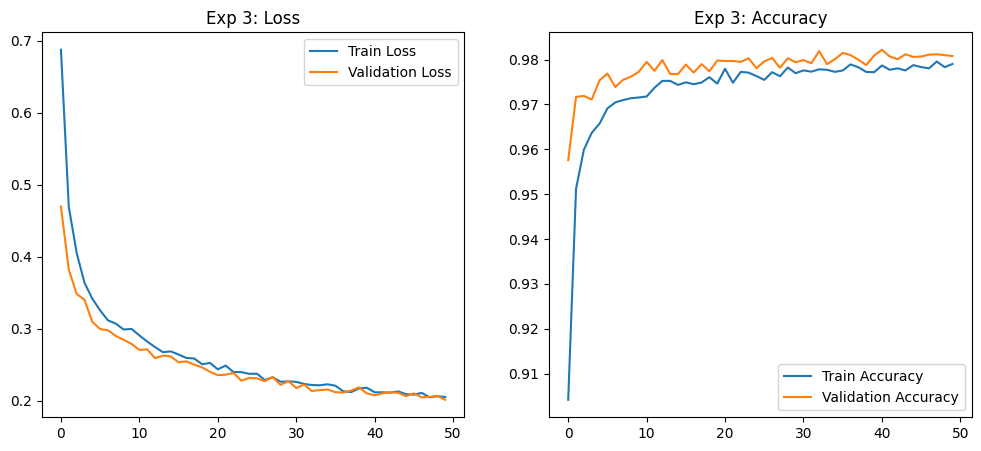

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


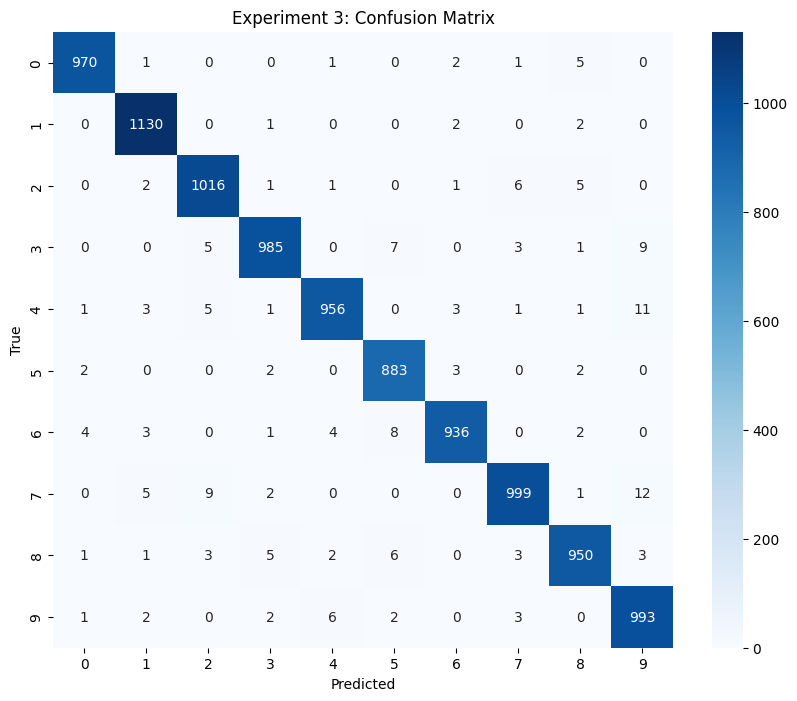

In [ ]:
# Evaluate and Plot Experiment 3
train_loss, train_accuracy = regularized_mlp_model.evaluate(x_train, y_train, verbose=0)
val_loss, val_accuracy = regularized_mlp_model.evaluate(x_val, y_val, verbose=0)
test_loss, test_accuracy = regularized_mlp_model.evaluate(x_test, y_test, verbose=0)

print(f"Experiment 3 - Training Accuracy   : {train_accuracy:.4f}, Loss: {train_loss:.4f}")
print(f"Experiment 3 - Validation Accuracy : {val_accuracy:.4f}, Loss: {val_loss:.4f}")
print(f"Experiment 3 - Test Accuracy       : {test_accuracy:.4f}, Loss: {test_loss:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_regularized_mlp.history['loss'], label='Train Loss')
plt.plot(history_regularized_mlp.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Exp 3: Loss")

plt.subplot(1, 2, 2)
plt.plot(history_regularized_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_regularized_mlp.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Exp 3: Accuracy")

plt.savefig(os.path.join(save_base_path, 'training_curves_regularized_mlp.png'))
plt.show()

# Confusion Matrix
y_pred_probs_reg = regularized_mlp_model.predict(x_test)
y_pred_reg = np.argmax(y_pred_probs_reg, axis=1)
cm_reg = tf.math.confusion_matrix(y_test, y_pred_reg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Experiment 3: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
